In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity, MultiShellBall3StickSharedDiffusivityGammaPrior
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../dmri/utils/pyloric_black.mplstyle")

# Ignore font warnings from matplotlib
import warnings
warnings.filterwarnings("ignore")
# Ignore missing font warnings from seaborn
warnings.filterwarnings("ignore", module="matplotlib.font_manager")


sim_type = MultiShellBall3StickSharedDiffusivityGammaPrior
ball_stick = sim_type.from_theta(np.random.randn(sim_type.theta_dim))

Duplicate key in file '../dmri/utils/pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')


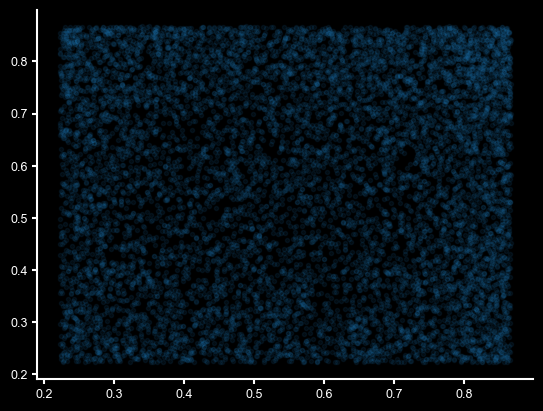

In [3]:
def soft_squash(signal, tau=0.8):
    # signal: arbitrary real
    # tau: temperature controls how sharp the transition is
    return jax.nn.sigmoid((signal - 0.5) / tau)


u = jax.random.uniform(jax.random.PRNGKey(0), (10000, 2), minval=-0.5, maxval=2.0)
plt.scatter(soft_squash(u[:,0]), soft_squash(u[:,1]), alpha=0.1)

In [4]:
from dmri.simulators.acquisition_scheme import acquisition_scheme, random_hcp_acquisition


@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4, rng5 = jax.random.split(rng, 6)
    acq = random_hcp_acquisition(rng)


    theta = jax.random.normal(rng1, shape=(sim_type.theta_dim,))
    rng_p, rng_m = jax.random.split(rng2)
    p_mask = jax.random.beta(rng_p, a=5, b=1, shape=(1,))
    model_mask = jax.random.bernoulli(rng_m, p=p_mask, shape=(len(sim_type.model_types)))
    #model_mask = jnp.ones(len(sim_type.model_types), dtype=jnp.bool)
    # This needs to have only one entry
    model_noise_idx = jax.random.randint(rng4, minval=0, maxval=len(sim_type.noise_types), shape=(1,))
    model_noise_mask = jnp.zeros(len(sim_type.noise_types), dtype=jnp.bool)
    model_noise_mask = model_noise_mask.at[model_noise_idx].set(True)
    model_mask = jnp.concatenate([model_mask, model_noise_mask], axis=-1)
    ball_stick = sim_type.from_theta(theta, model_mask=model_mask)

    @jax.grad
    def posterior_score(theta, x):
        ball_stick = sim_type.from_theta(theta, model_mask=model_mask)
        return ball_stick.log_likelihood(acq, x) + jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)

    x_o = ball_stick.signal(acq, rng=rng5)
    score = posterior_score(theta, x_o)
    return p_mask, model_mask, theta, x_o, acq, score


In [5]:
p_mask,masks, theta, x_o, acq, score= jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=50))

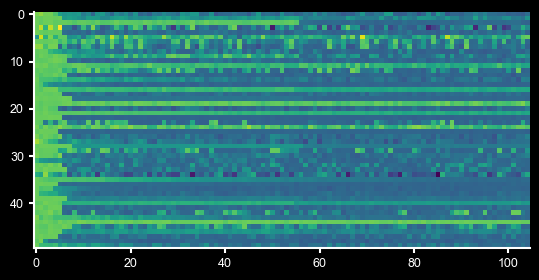

In [6]:
import matplotlib.pyplot as plt
plt.imshow(x_o)

In [7]:
from dmri.nn.dmri_reconstruction_model import DMRIInferenceModel, DMRIInferenceModelConfig, DMRIInferenceModelConfigMaskPriorAmortized, DMRIInferenceModelConfigMaskPriorAmortizedPP
from dmri.nn.tokenizer import DMRITokenizerPP

cfg = DMRIInferenceModelConfigMaskPriorAmortizedPP(sim_type, use_attention_mask=True)
cfg.theta_inference_cfg.widening_factor = 4
cfg.theta_inference_cfg.num_heads = 8
cfg.theta_inference_cfg.num_layers=12
cfg.theta_inference_cfg.attn_size = 8
cfg.theta_inference_cfg.gate_attention = True
cfg.embedding_cfg.use_global_summary_token = True
cfg.model_dim=128
model = DMRIInferenceModel(cfg, nnx.Rngs(0))

In [8]:
acq_single = jax.tree_util.tree_map(lambda x: x[0], acq)
x_o_single = x_o[0]

In [9]:
jax.jit(model.sample_mask)(jax.random.PRNGKey(0), acq_single, x_o_single, jnp.array([0.5]))

Array([ True,  True, False,  True,  True], dtype=bool)

In [16]:
masks[0]

Array([ True,  True, False,  True,  True], dtype=bool)

In [11]:
theta = jax.jit(model.sample_theta)(jax.random.PRNGKey(0), acq_single, x_o_single, masks[0])

In [12]:
jax.jit(model.log_prob_theta)(theta, acq_single, x_o_single, masks[0])

(12,) (16,) (105, 128) (128,)


Array(-20.441, dtype=float32)

In [7]:
import optax

optimizer = optax.chain(optax.radam(1e-4))

params = nnx.state(model, nnx.Param)
opt_state = optimizer.init(params)


In [8]:
from dmri.train.dataloader import StreamDataLoader
from probjax.utils.bmutil import benchmark

dataloader = StreamDataLoader(simulator, batch_size=64, num_producers=1,max_queue_size=1000, data_device="cpu")

In [9]:
dataloader.queue_size()

51

In [10]:
datastream = iter(dataloader)

In [11]:
xs = next(datastream)
p_mask, model_mask, theta,  xs, acq, score = xs

In [12]:
theta.shape

(64, 12)

In [16]:
model(model_mask=model_mask, acq=acq, x=xs, theta=theta, t=jnp.ones((64,1)))

(Array([[-2.156, -1.814, -1.443, -1.543, -1.418],
        [-2.151, -1.905, -1.484, -1.589, -1.44 ],
        [-0.579,  0.238,  1.314,  1.145,  1.334],
        [-0.583,  0.704,  1.617,  1.623,  1.779],
        [-0.843, -0.24 ,  0.567,  0.415,  0.416],
        [-2.219, -1.964, -1.524, -1.635, -1.48 ],
        [-0.703,  0.064,  1.175,  0.983,  1.09 ],
        [-0.518,  0.334,  1.038,  0.914,  1.052],
        [-0.888, -0.322,  0.148,  0.012,  0.046],
        [-2.162, -1.925, -1.483, -1.663, -1.58 ],
        [-2.202, -1.944, -1.536, -1.645, -1.51 ],
        [-0.635,  0.599,  1.542,  1.49 ,  1.664],
        [-2.176, -1.923, -1.503, -1.687, -1.482],
        [-0.622,  0.333,  1.126,  1.079,  1.213],
        [-0.495,  0.765,  1.712,  1.697,  1.754],
        [-0.871, -0.447,  0.347,  0.171,  0.225],
        [-0.747,  0.107,  1.073,  0.887,  1.017],
        [-2.196, -1.963, -1.542, -1.624, -1.725],
        [-0.827, -0.257,  0.54 ,  0.308,  0.4  ],
        [-0.706, -0.036,  0.783,  0.537,  0.722],


In [ ]:


def loss_fn(params, data, rng):
    nnx.update(model, params)
    p_mask, model_mask, theta,  xs, acq, score = data
    bvals, bvecs = acq.bvals, acq.bvecs
    rng0, rng1 = jax.random.split(rng, 2)
    tokens_cfg = model.tokenizer.embed_cfgs(
            model_mask, sim_type.fraction_prior, tuple(sim_type.model_types), tuple(sim_type.noise_types)
        )
        # Embed observatiosn
    y = model.encoder(bvals, bvecs, xs)
    if y.ndim == 2:
        y = y[..., None, :]

    t = model.inference_decoder.noise_schedule(rng0, (theta.shape[0],))
    thetas_noisy = theta + t * jax.random.normal(rng1, theta.shape)

    theta_denoised = model.inference_decoder(t,thetas_noisy, model.tokenizer, y, model_mask=model_mask, tokens_cfg=tokens_cfg)
    score_est = (theta_denoised - thetas_noisy) / t**2
    #print(score_est[t[...,0] < 0.01])
    weight1 = model.inference_decoder.weight_fn(t)#*jnp.where((t > 0.05), 1, 0)
    #weight2 = 0.5*t**2*jnp.where((t < 0.1), 1, 0)
    score_target_norm = jnp.sum(score**2, axis=-1, keepdims=True)
    weight2 = jnp.where((t < 0.1), 1, 0) * 1/score_target_norm * 1/t
    print(jnp.where((t < 0.1), 1, 0).sum())
    print("Score target norm", score_target_norm.mean())
    loss_denoised = weight1*jnp.sum((theta_denoised - theta)**2, axis=-1, keepdims=True)
    loss_score = weight2*jnp.sum((score_est - score)**2, axis=-1, keepdims=True)

    print(jnp.mean(loss_denoised), jnp.mean(loss_score))

    return jnp.mean(loss_denoised + loss_score)
    # attention_mask = model.marginalization_mask(model_mask)
    # loss = model.inference_decoder.loss(rng, theta, model.tokenizer, y, model_mask, tokens_cfg, target_score=score, attention_mask=attention_mask, loss_mask=None, weight_by_complexity=True)
    # # loss = model.loss_fn(rng, model_mask, theta, xs, acq.bvals, acq.bvecs, target_score=score, mask_prior=p_mask, weight_by_complexity=True)
    # return loss.sum()

@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

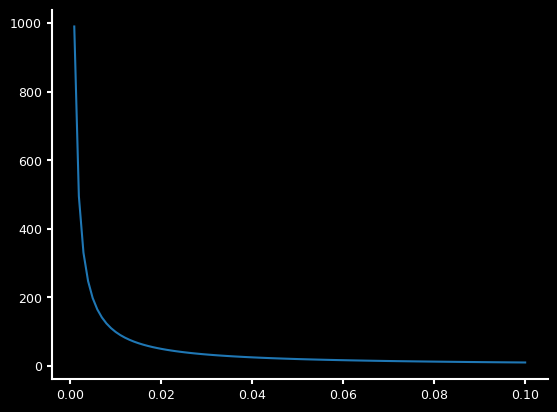

In [ ]:
ts = jnp.linspace(0, 0.1, 100)
plt.plot(ts, 1/ts)


In [91]:
opt_state = optimizer.init(params)

In [98]:
loss_fn(params, next(iter(dataloader)), jax.random.PRNGKey(2))

755
Score target norm 31748812.0
10.116123 3.7552176


Array(13.871, dtype=float32)

In [96]:
key = jax.random.PRNGKey(0)

In [97]:
data_stream = iter(dataloader)
for i in range(0,100):
    l = 0
    for j in range(50):
        key, subkey2 = jax.random.split(key, 2)
        x = next(data_stream)
        params, opt_state, loss = update(params, opt_state, x, subkey2)
        l += loss
    print(l/50)

Traced<ShapedArray(int32[])>with<DynamicJaxprTrace>
Score target norm Traced<ShapedArray(float32[])>with<DynamicJaxprTrace>
Traced<ShapedArray(float32[])>with<JVPTrace> with
  primal = Traced<ShapedArray(float32[])>with<DynamicJaxprTrace>
  tangent = Traced<ShapedArray(float32[])>with<JaxprTrace> with
    pval = (ShapedArray(float32[]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x15412caf7e90>, in_tracers=(Traced<ShapedArray(float32[4096,1]):JaxprTrace>,), out_tracer_refs=[<weakref at 0x15412c705440; to 'JaxprTracer' at 0x15412c7053f0>], out_avals=[ShapedArray(float32[])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[4096,1]. let
    b:f32[] = reduce_sum[axes=(0, 1)] a
    c:f32[] = div b 4096.0
  in (c,) }, 'in_shardings': (UnspecifiedValue,), 'out_shardings': (UnspecifiedValue,), 'in_layouts': (None,), 'out_layouts': (None,), 'donated_invars': (False,), 'ctx_mesh': None, 'name': '_mean', 'keep_unused': False, 'inline': True, 'compiler_options_kvs': ()}, effects=

In [204]:
# import pickle
# pickle.dump(params, open("params.pkl", "wb"))

In [24]:
# import pickle
# params = pickle.load(open("ema_params.pkl", "rb"))

In [105]:
nnx.update(model, params)

In [106]:
batch_simulator = jax.jit(jax.vmap(simulator))
p_mask, masks, thetas, x_os, acq, score = batch_simulator(jax.random.split(jax.random.key(1), 100))

In [107]:
tokens_cfg = model.tokenizer.embed_cfgs(
        masks, sim_type.fraction_prior, tuple(sim_type.model_types), tuple(sim_type.noise_types)
    )
    # Embed observatiosn
y = model.encoder(acq.bvals, acq.bvecs, x_os)
if y.ndim == 2:
    y = y[..., None, :]

In [108]:
score_pred = model.inference_decoder.score(
            jnp.ones((thetas.shape[0],1))*0.1,
            thetas,
            model.tokenizer,
            y=y,
            tokens_cfg=tokens_cfg,
            model_mask=masks,
            attention_mask=model.marginalization_mask(masks)
        )

In [109]:
jnp.sum((score_pred - score)**2, axis=-1).mean()

Array(22963366., dtype=float32)

In [110]:
# Consine similarity
jnp.mean(jnp.sum(score_pred*score, axis=-1) / (jnp.linalg.norm(score_pred, axis=-1)*jnp.linalg.norm(score, axis=-1)))

Array(0.128, dtype=float32)

[ True  True  True  True  True]


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

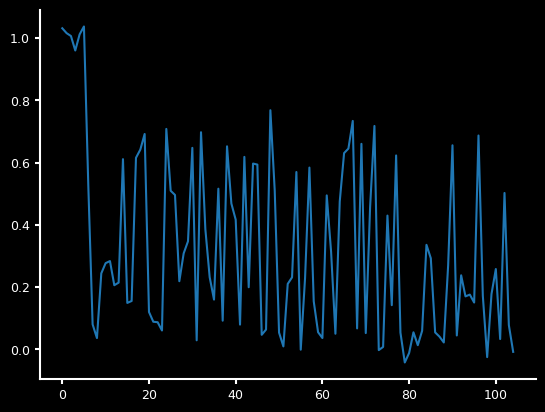

In [111]:
#idx = 2
idx = 45
print(masks[idx])
plt.plot(x_os[idx])

In [92]:
from functools import partial

In [93]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=64, max_noise=40, model_mask=masks[idx]), in_axes=(0,None,None, None))(jax.random.split(jax.random.key(0), 4096), acq.bvals[idx], acq.bvecs[idx], x_os[idx])

[ True  True  True]
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
[ True  True  True]


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

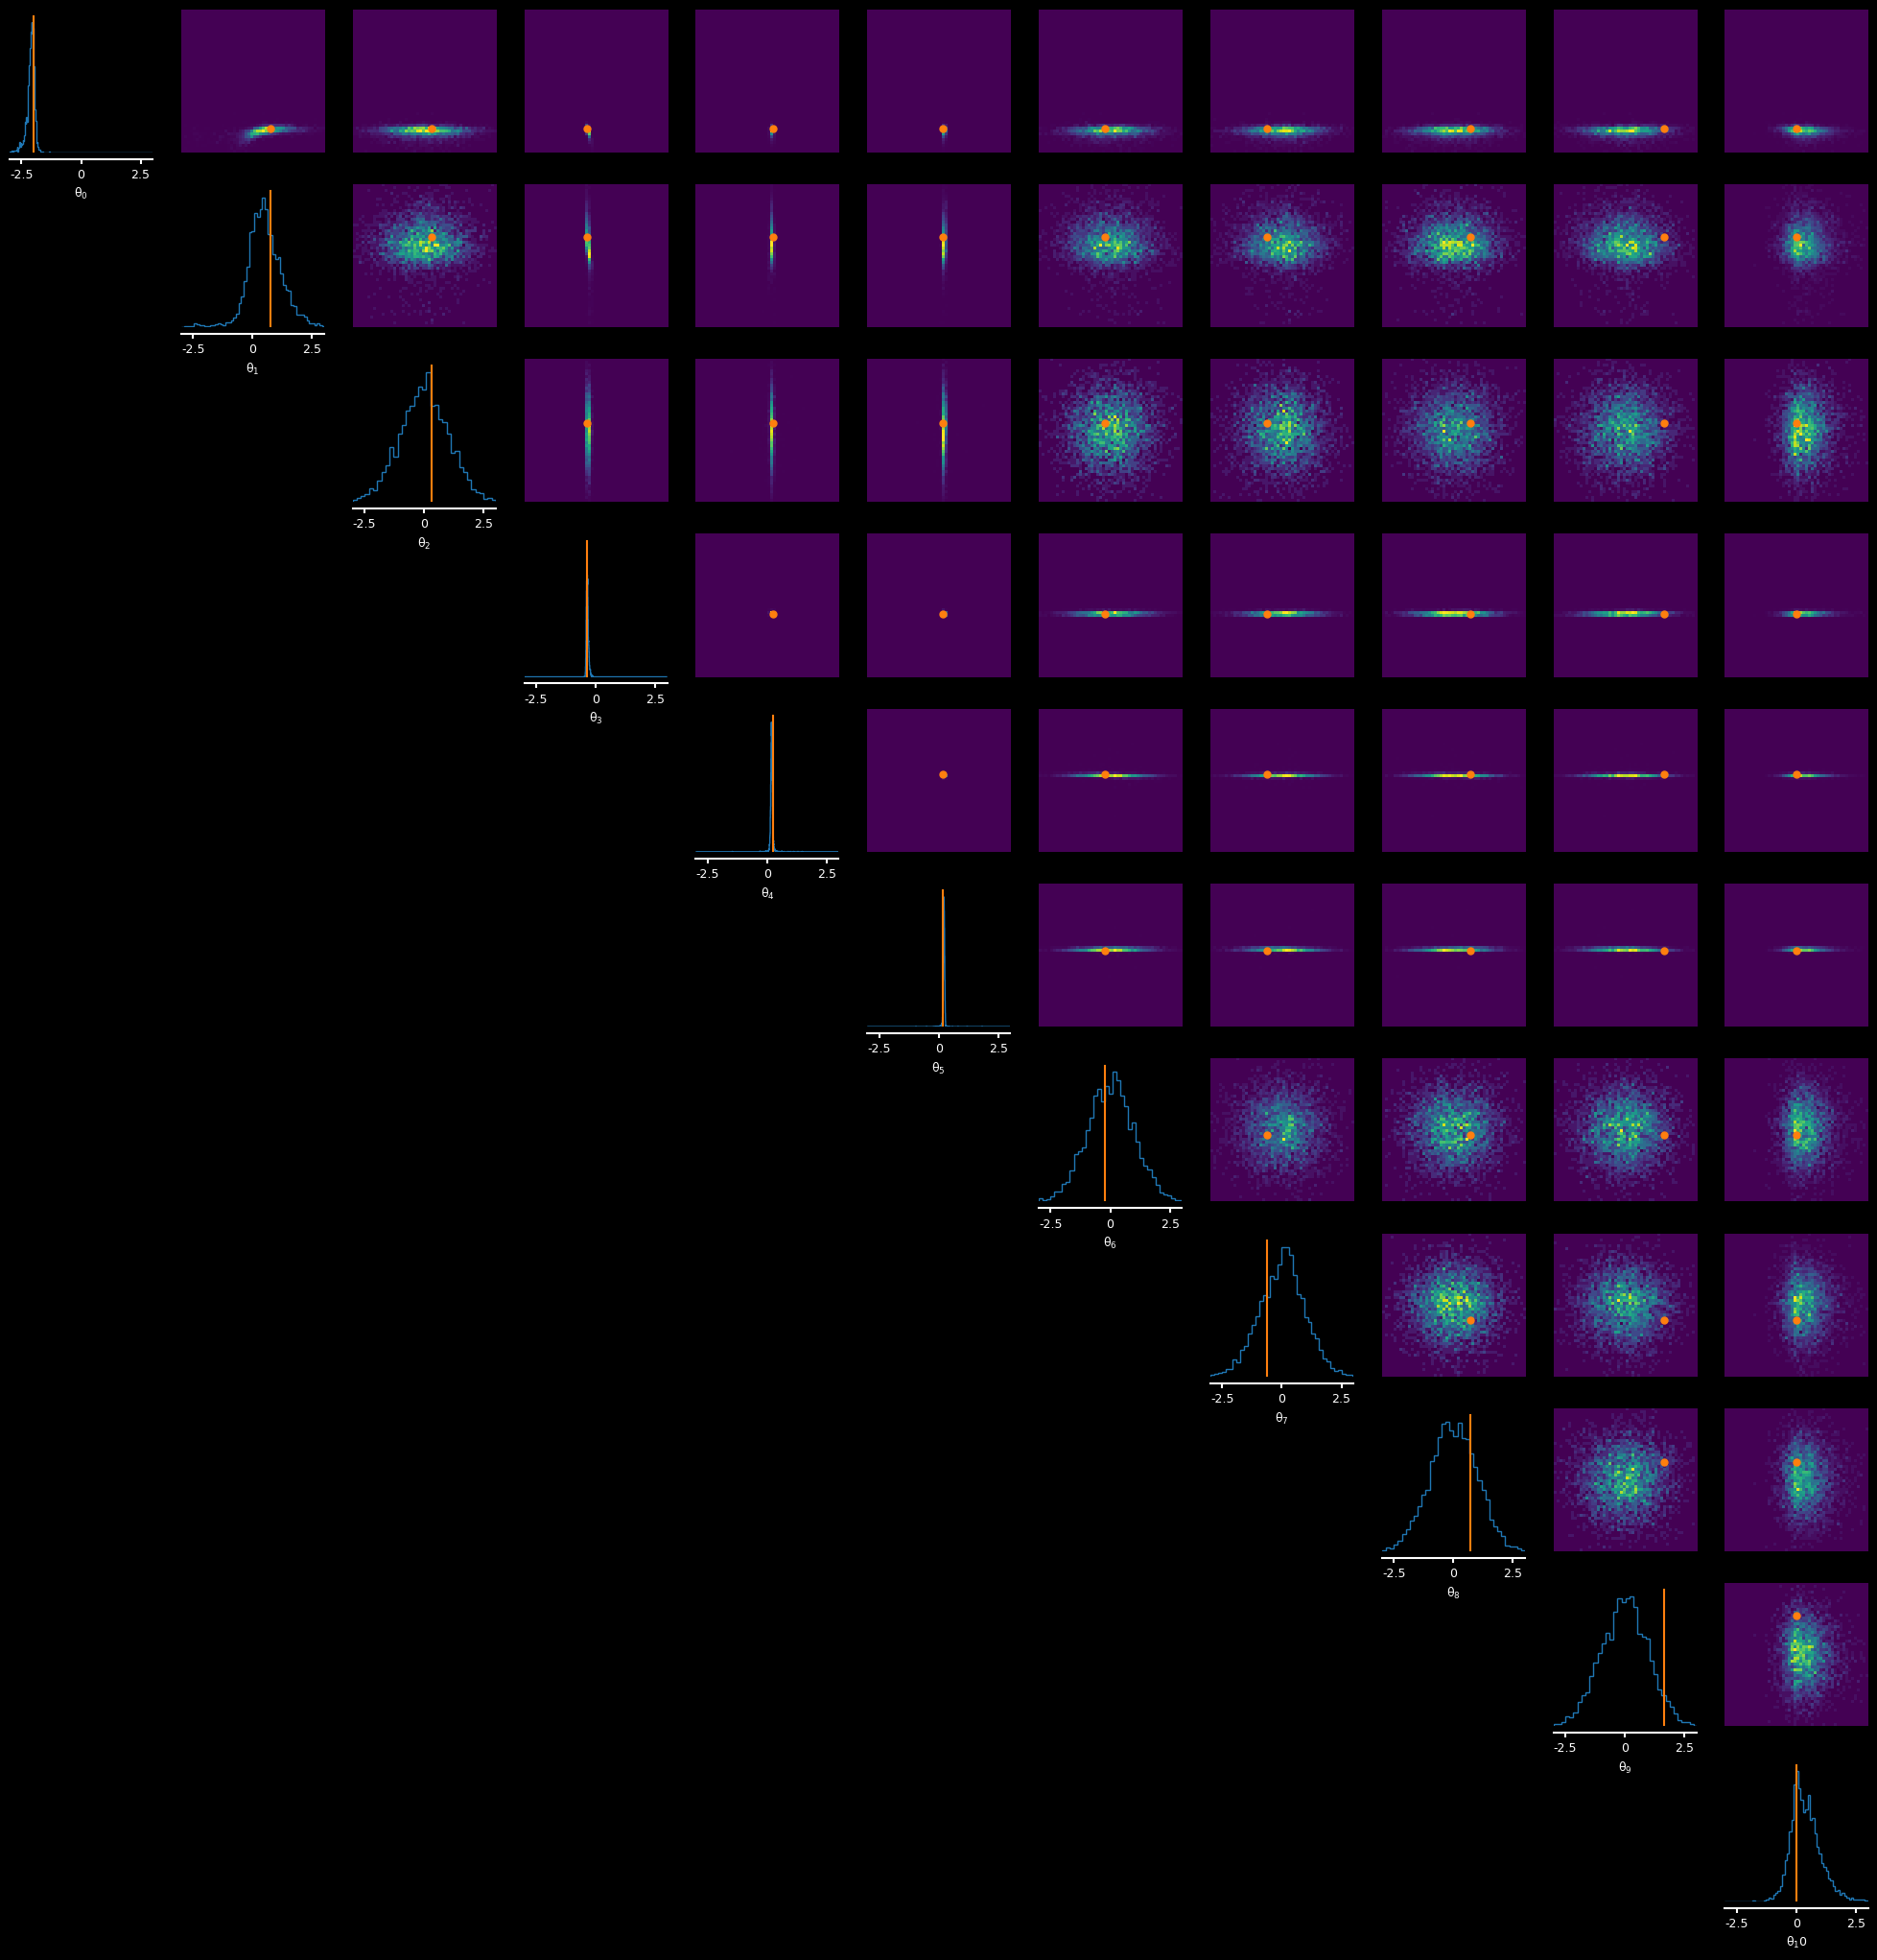

In [94]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(thetas_post, points=[thetas[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [95]:
from blackjax import hmc, tempered_smc,mala
from blackjax.smc.resampling import systematic


In [96]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=masks[idx]).signal(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), rng=rng)

def log_likelihood_fn(theta):
    simulator = sim_type.from_theta(theta, model_mask=masks[idx])
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x_os[idx])
    return ll

def log_prior_fn(theta):
    return jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)


In [97]:

@jax.jit
def smc(thetas):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.01, num_integration_steps=10, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic

    smc = tempered_smc(log_prior_fn, log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 1)
    state = smc.init(thetas)
    state =state._replace(lmbda=0.99)

    def step(state, rng):
        state, i = state
        lmbda = 0.99 + i*0.01/5
        new_state, info = smc.step(rng, state, lmbda)
        ess = 1/jnp.sum(new_state.weights**2)
        acc_rate = info.update_info.acceptance_rate
        jax.debug.print("ESS: {ess}, acc_rate: {acc_rate}", ess=ess, acc_rate=acc_rate.mean())
        return (new_state, i+1), info

    rng_keys = jax.random.split(jax.random.key(0), 5)
    final_state, _ = jax.lax.scan(step, (state, 0), rng_keys)
    return final_state[0].particles


In [98]:
particles =smc(thetas_post)

ESS: 4096.0, acc_rate: 0.001220703125
ESS: 3299.420654296875, acc_rate: 0.0014560108538717031
ESS: 3741.510009765625, acc_rate: 0.001279179472476244
ESS: 3887.455078125, acc_rate: 0.0009438855922780931
ESS: 3956.685546875, acc_rate: 0.0008396129123866558


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

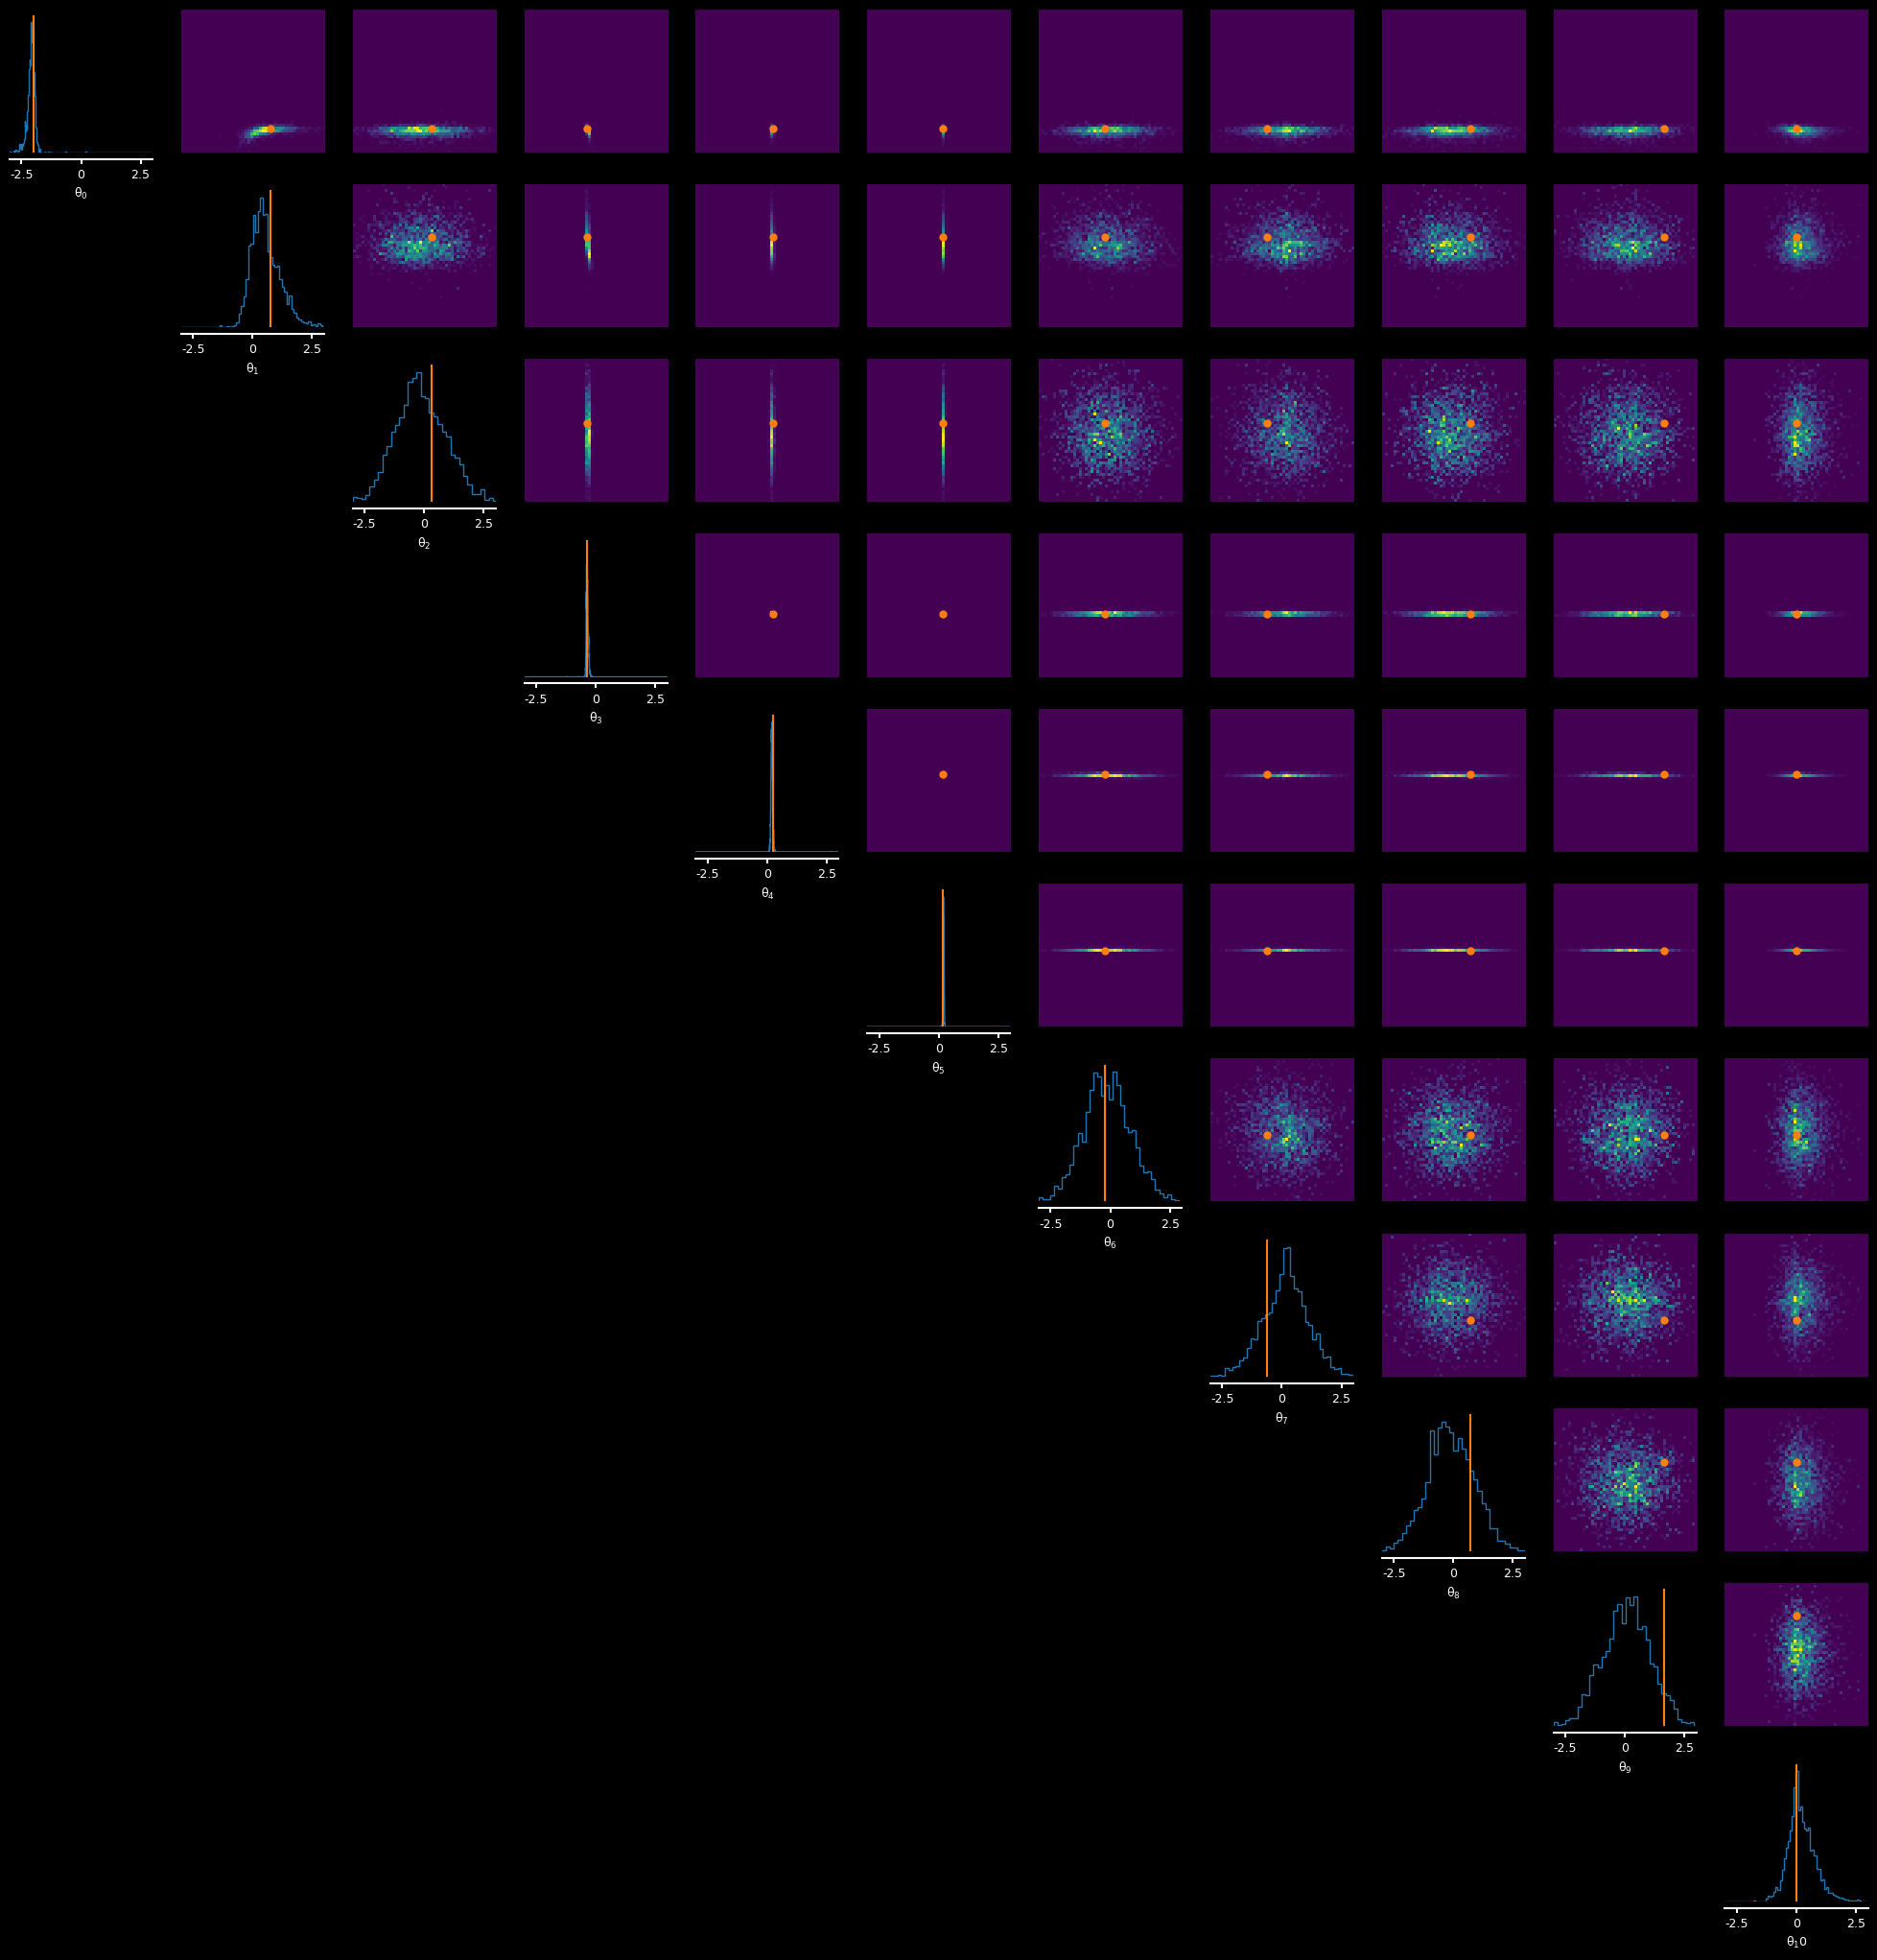

In [99]:
_ = pairplot(particles, points=[thetas[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

Text(0, 0.5, 'MRI Signal')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

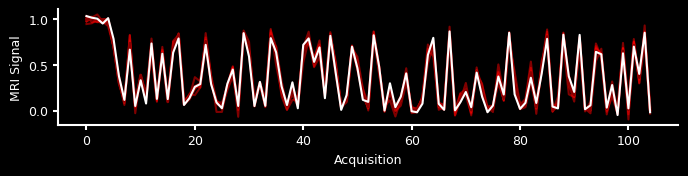

In [100]:

posterior_preds = jax.vmap(posterior_pred)(particles, jax.random.split(jax.random.key(0), 4096))
bvals = acq.bvals[idx]
bvecs = acq.bvecs[idx]
sort_bvals = jnp.argsort(bvals)
bvals = bvals[sort_bvals]
posterior_preds_sorted = posterior_preds[:,sort_bvals]
x_o = x_os[idx][sort_bvals]


fig = plt.figure(figsize=(8, 1.5))

_ = plt.plot(posterior_preds_sorted[:5].T, label="posterior pred", color="red", alpha=0.5)
_ = plt.plot(posterior_preds_sorted.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

# fig.savefig(f"../figures/posterior_pred_idx={idx}.svg")
# fig.savefig(f"../figures/posterior_pred_idx={idx}.png")

In [340]:
def loglikelihood(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_posterior(theta, mask, acq, x):
    theta_mask = model.tokenizer.theta_mask(mask)
    return loglikelihood(theta, mask, acq, x) + (theta_mask*jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)).sum()

def log_q(theta, mask, acq, x):
    return model.log_prob_theta(theta, acq.bvals, acq.bvecs, x, num_steps=512, max_noise=20, model_mask=mask)

@jax.grad
def true_score(theta, mask, acq, x):
    return log_posterior(theta, mask, acq, x).sum()


@jax.jit
def effectve_sample_size(thetas):
    logp = jax.vmap(partial(log_posterior, mask=masks[idx], acq=acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x=x_os[idx]))(thetas)
    logq = jax.vmap(partial(log_q, mask=masks[idx], acq=acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x=x_os[idx]))(thetas)
    log_w = logp - logq
    # Self normalized importance weights
    w = jax.nn.softmax(log_w)
    return 1/jnp.sum(w**2)


In [52]:
effectve_sample_size(thetas_post)

Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>


Array(1.377, dtype=float32)

In [29]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti

import numpy as np

data, affine = load_nifti("data/data.nii.gz")
brain_mask, _ = load_nifti("data/nodif_brain_mask.nii.gz")
_bvals, bvecs = read_bvals_bvecs("data/bvals", "data/bvecs")

# Round bvals to nearest (0, 1000, 2000)
bvals_rounded = np.round(_bvals / 1000) * 1000
bvals = np.clip(bvals_rounded, 0, 2000)
b0_mask = bvals == 0

S0 = np.mean(data[..., b0_mask], -1)

data_norm = data / S0[..., None]
data_norm = np.where(brain_mask[...,None], data_norm, 0.)
data_norm = np.where(np.isnan(data_norm), 0., data_norm)
S0 = np.where(brain_mask, S0, 0.)

In [30]:
idx = np.argsort(bvals)

bvals = bvals[idx]
bvecs = bvecs[idx]
data_norm = data_norm[...,idx]


In [31]:
full_data_flat = data_norm.reshape(-1, data_norm.shape[-1])
brain_mask_flat = brain_mask.reshape(-1)

full_data_flat_in_brain = full_data_flat[brain_mask_flat.astype(np.bool),:]

In [32]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


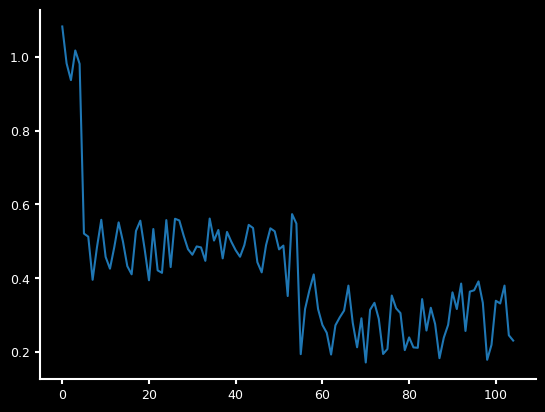

In [33]:
plt.plot(full_data_flat_in_brain[21_800])

In [34]:
x_o = full_data_flat_in_brain[21_800]

In [35]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=32, max_noise=80, model_mask=jnp.ones(5, dtype=jnp.bool)), in_axes=(0,None,None, None))(jax.random.split(jax.random.key(0), 4096), acq.bvals, acq.bvecs, x_o)

[ True  True  True]
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
[ True  True  True]


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following famil

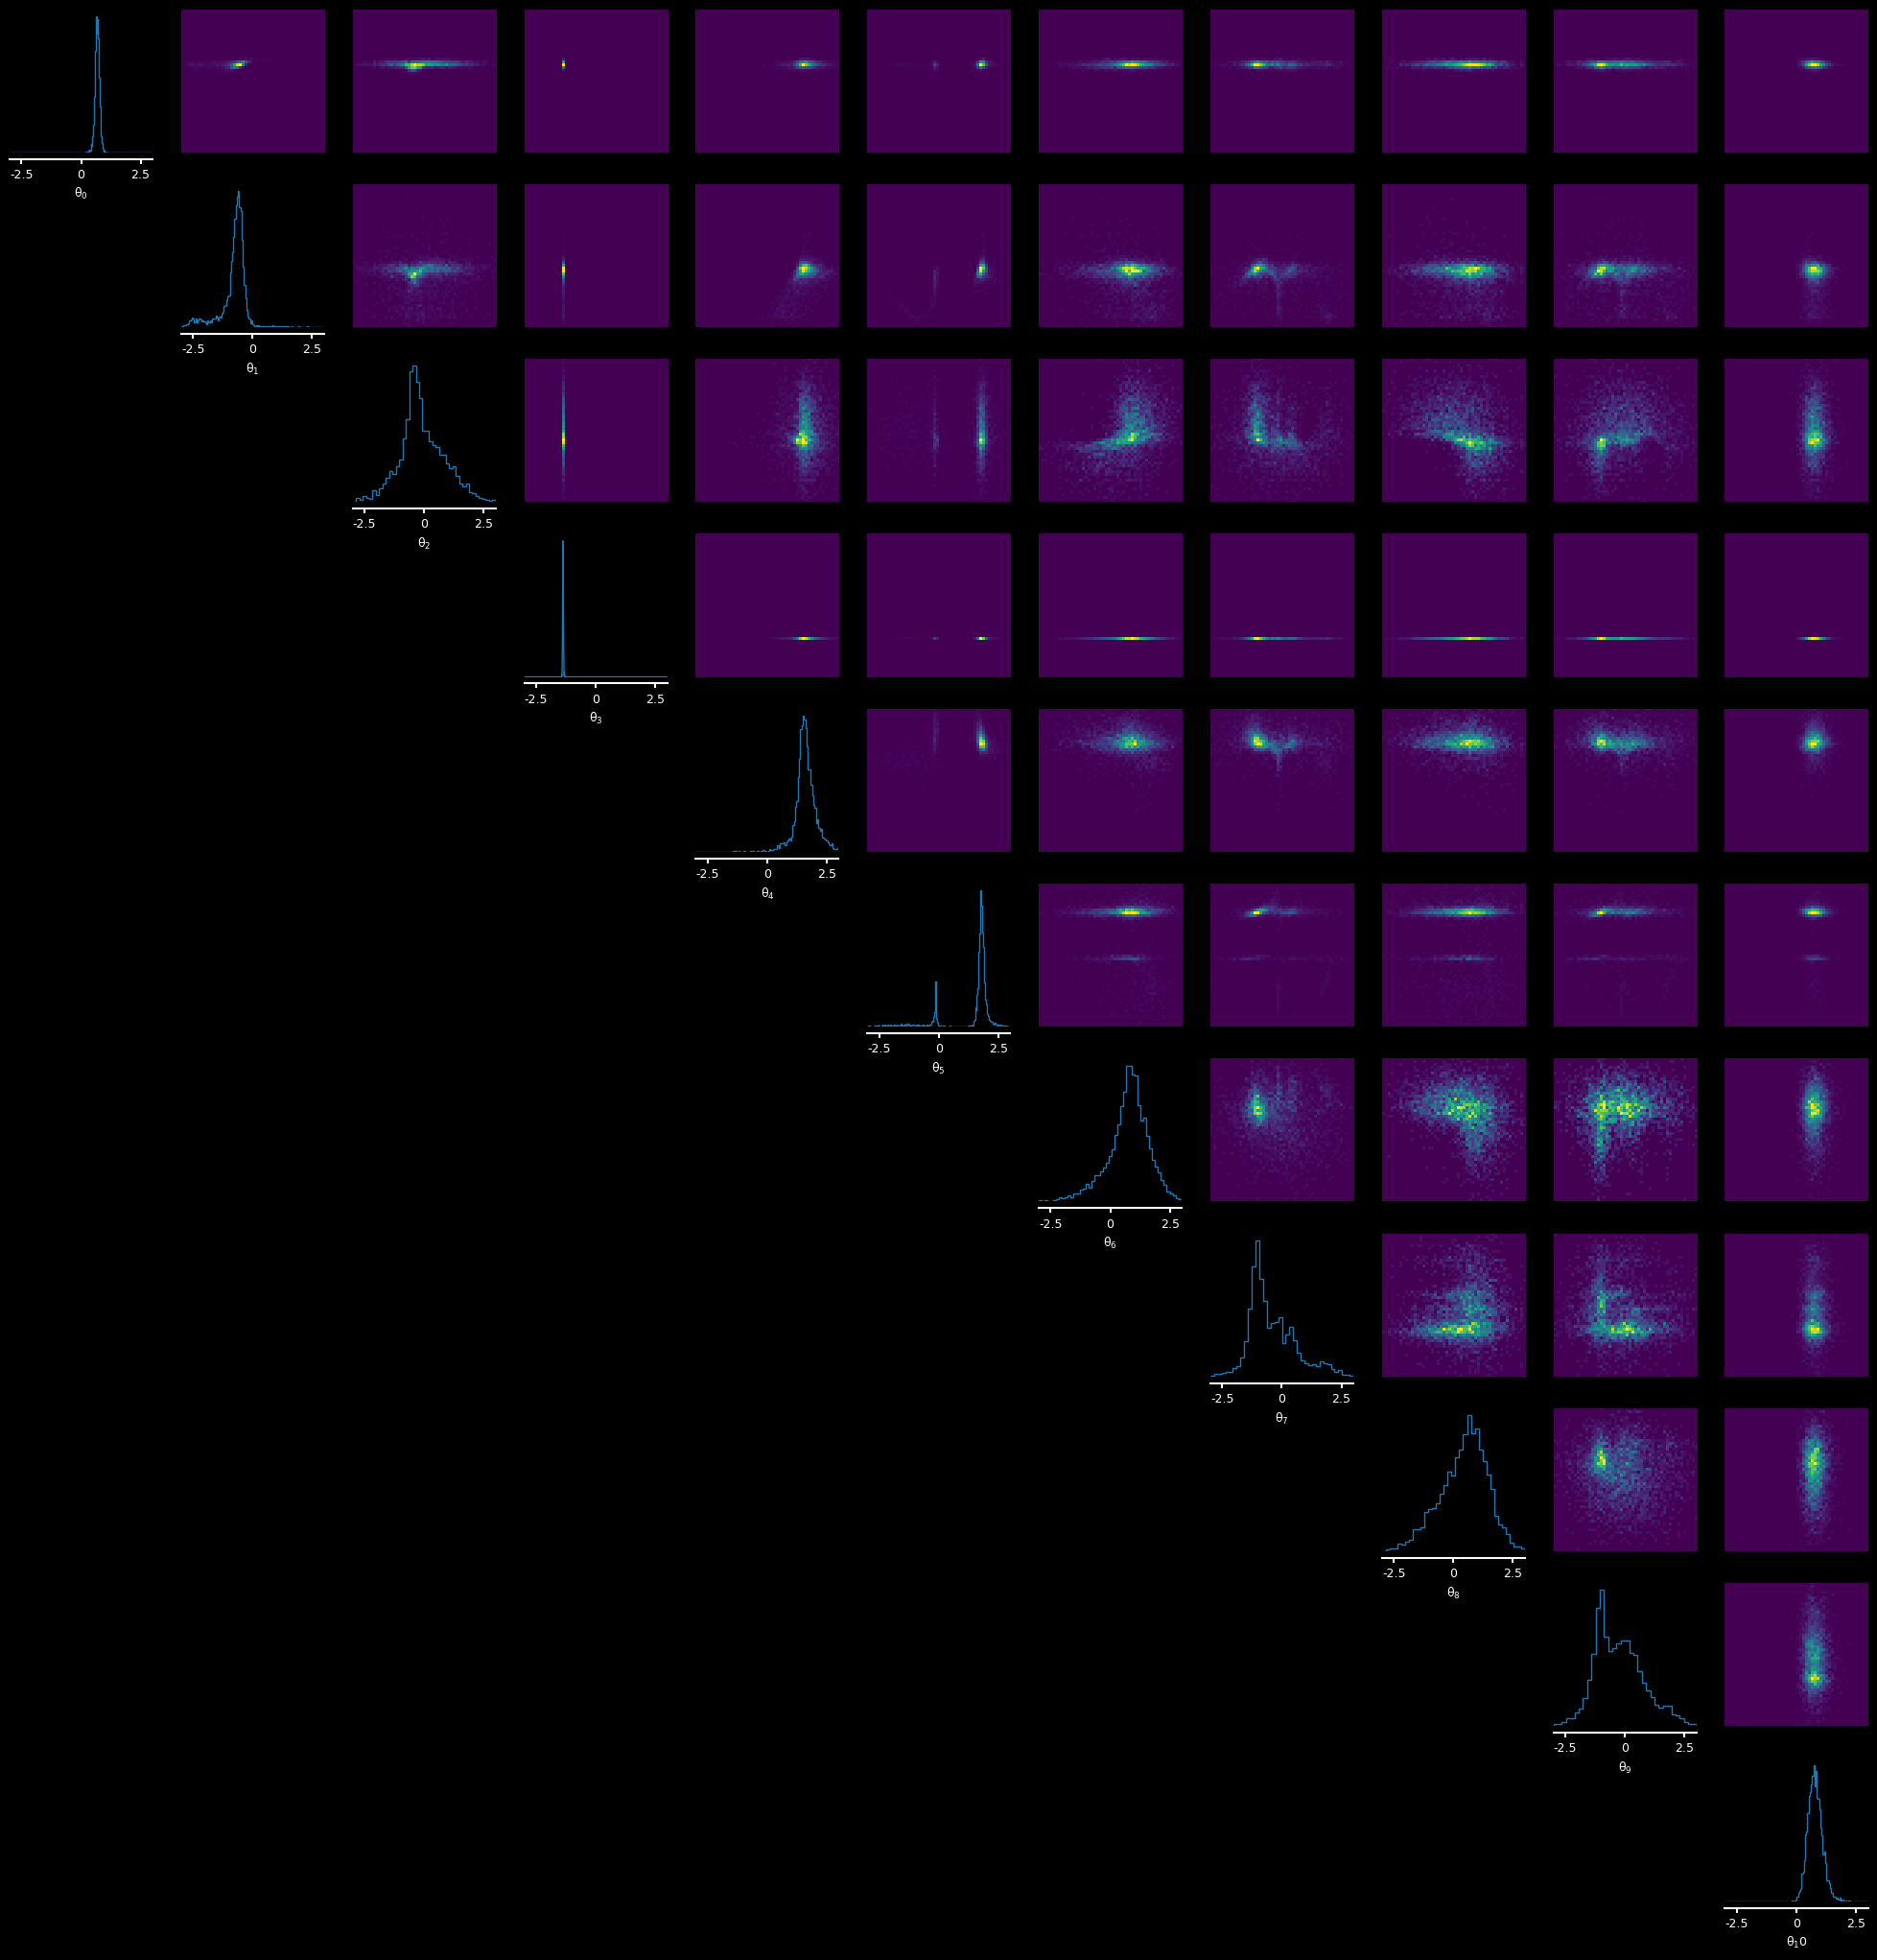

In [38]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(thetas_post, limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [46]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=jnp.ones(5, dtype=jnp.bool)).signal(acq, rng=rng)

def log_likelihood_fn(theta):
    simulator = sim_type.from_theta(theta, model_mask=jnp.ones(5, dtype=jnp.bool))
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals, acq.bvecs), x_o)
    return ll

def log_prior_fn(theta):
    return jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)

@jax.jit
def smc(thetas):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.01, num_integration_steps=5, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic

    smc = tempered_smc(log_prior_fn, log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 1)
    state = smc.init(thetas)
    state =state._replace(lmbda=1.)

    def step(state, rng):
        new_state, info = smc.step(rng, state, 1.)
        ess = 1/jnp.sum(new_state.weights**2)
        acc_rate = info.update_info.acceptance_rate
        jax.debug.print("ESS: {ess}, acc_rate: {acc_rate}", ess=ess, acc_rate=acc_rate.mean())
        return new_state, info

    rng_keys = jax.random.split(jax.random.key(0), 20)
    final_state, _ = jax.lax.scan(step, state, rng_keys)
    return final_state.particles


In [47]:
particles =smc(thetas_post)

ESS: 4096.0, acc_rate: 0.1103493869304657
ESS: 4096.0, acc_rate: 0.11868885159492493
ESS: 4096.0, acc_rate: 0.11102443933486938
ESS: 4096.0, acc_rate: 0.11853062361478806
ESS: 4096.0, acc_rate: 0.11324401199817657
ESS: 4096.0, acc_rate: 0.12045001238584518
ESS: 4096.0, acc_rate: 0.11812685430049896
ESS: 4096.0, acc_rate: 0.1134510412812233
ESS: 4096.0, acc_rate: 0.11267013102769852
ESS: 4096.0, acc_rate: 0.11641153693199158
ESS: 4096.0, acc_rate: 0.10789307206869125
ESS: 4096.0, acc_rate: 0.11298280954360962
ESS: 4096.0, acc_rate: 0.11612764000892639
ESS: 4096.0, acc_rate: 0.12300335615873337
ESS: 4096.0, acc_rate: 0.11899308860301971
ESS: 4096.0, acc_rate: 0.11987312138080597
ESS: 4096.0, acc_rate: 0.12133219838142395
ESS: 4096.0, acc_rate: 0.12142932415008545
ESS: 4096.0, acc_rate: 0.12551365792751312
ESS: 4096.0, acc_rate: 0.12246876955032349


Text(0, 0.5, 'MRI Signal')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

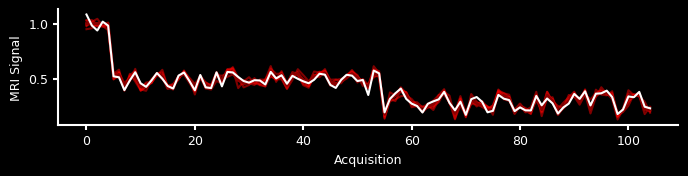

In [48]:

posterior_preds = jax.vmap(posterior_pred)(particles, jax.random.split(jax.random.key(0), 4096))


fig = plt.figure(figsize=(8, 1.5))

_ = plt.plot(posterior_preds[:5].T, label="posterior pred", color="red", alpha=0.5)
_ = plt.plot(posterior_preds.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

# fig.savefig(f"../figures/posterior_pred_idx={idx}.svg")
# fig.savefig(f"../figures/posterior_pred_idx={idx}.png")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

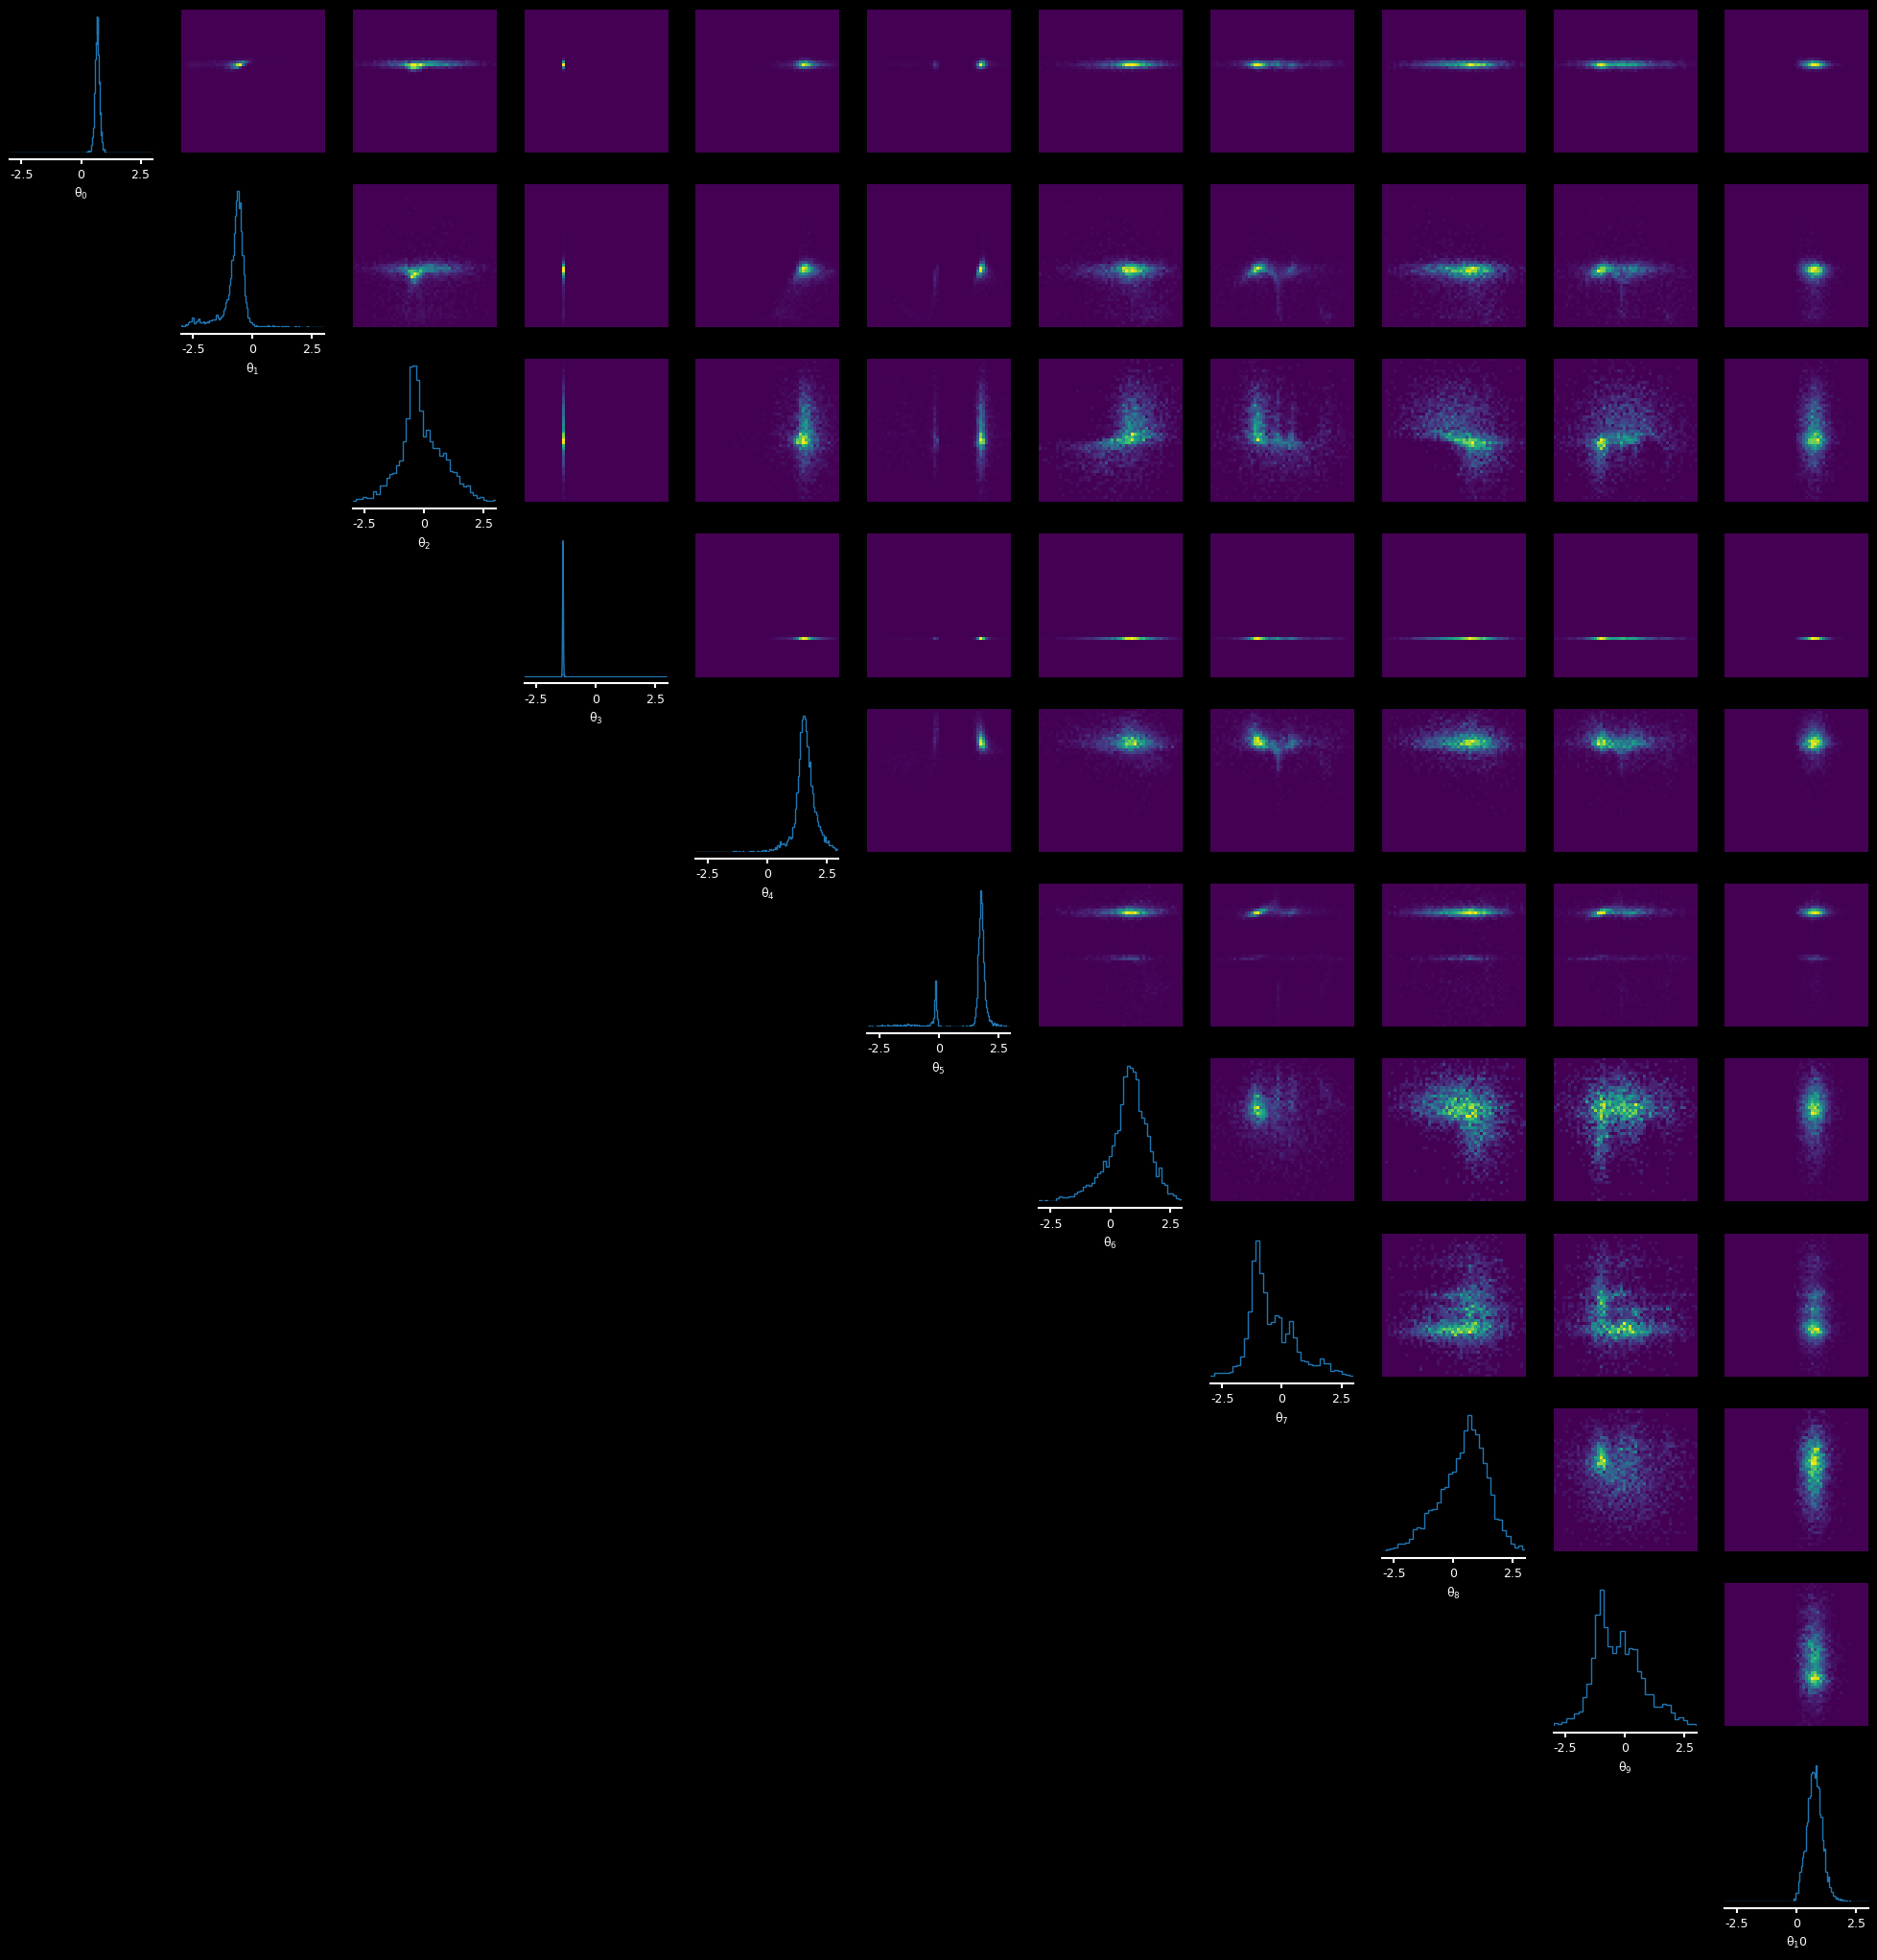

In [49]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(particles, limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [187]:
model_mask = jnp.array([True, True, True, True, True], dtype=jnp.bool)

def log_likelihood_fn(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_prior_fn(theta):
    return jax.scipy.stats.norm.logpdf(theta, 0, 1).sum()

def posterior_pred(theta, rng):
    return sim_type.from_theta(theta, model_mask=model_mask).signal(acq, rng=rng)

def smc(rng,thetas,model_mask, acq, x_o):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.015, num_integration_steps=5, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic
    _log_likelihood_fn = partial(log_likelihood_fn, mask=model_mask, acq=acq, x=x_o)
    smc = tempered_smc(log_prior_fn, _log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 1)
    state = smc.init(thetas)
    state =state._replace(lmbda=1.)

    def step(state, rng):
        new_state, info = smc.step(rng, state, 1.)
        return new_state, info

    rng_keys = jax.random.split(rng, 10)
    final_state, _ = jax.lax.scan(step, state, rng_keys)
    return final_state.particles, final_state.weights


def sample_mcmc_correct(key, x):
    key, subkey = jax.random.split(key)
    K = 50
    propose_fn = partial(model.sample_theta, num_steps=32, max_noise=80)
    key_k = jax.random.split(key, K)
    theta = jax.vmap(propose_fn, in_axes=(0,None,None,None, None))(key_k, acq.bvals, acq.bvecs, x,model_mask)
    theta_corr, weights = smc(subkey, theta, model_mask, acq, x)
    return theta_corr, weights

sample_theta_per_x = jax.jit(jax.vmap(sample_mcmc_correct))

In [183]:
full_data_flat_in_brain = np.nan_to_num(full_data_flat_in_brain, nan=0, posinf=0, neginf=0)

In [200]:
thetas_corr, weights = sample_theta_per_x(jax.random.split(jax.random.key(0), 30000), full_data_flat_in_brain[1000:31000])
ess = jnp.mean(1/jnp.sum(weights**2, axis=-1) / 50)
print(ess)


Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>


2025-05-08 11:02:53.862847: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 21.02GiB (22568184094 bytes) by rematerialization; only reduced to 37.55GiB (40320000000 bytes), down from 37.55GiB (40320000000 bytes) originally
2025-05-08 11:02:54.153744: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 21.02GiB (22568184094 bytes) by rematerialization; only reduced to 37.55GiB (40320000000 bytes), down from 37.55GiB (40320000000 bytes) originally
2025-05-08 11:02:54.160501: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 21.02GiB (22568184094 bytes) by rematerialization; only reduced to 37.55GiB (40320000000 bytes), down from 37.55GiB (40320000000 bytes) originally
2025-05-08 11:02:54.228204: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 21.02GiB (225681840

XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 40320000000 bytes.

In [186]:
thetas_corr.shape

(20000, 50, 11)

In [194]:
xs_pred = jax.vmap(jax.vmap(posterior_pred, in_axes=(0,None)))(thetas_corr, jax.random.split(jax.random.key(0), 20000))

In [195]:
xs_pred

(20000, 50, 105)

In [197]:
(xs_pred.mean(1) - full_data_flat_in_brain[1000:21000]).mean(0)

Array([-0.021, -0.008,  0.011,  0.007,  0.014, -0.021, -0.015, -0.017,
       -0.013, -0.016, -0.012, -0.01 , -0.016, -0.018, -0.011, -0.018,
       -0.013, -0.012, -0.013, -0.008, -0.009, -0.011, -0.011, -0.013,
       -0.015, -0.01 , -0.018, -0.015, -0.014, -0.013, -0.014, -0.018,
       -0.011, -0.01 , -0.005, -0.01 , -0.014, -0.006, -0.012, -0.011,
       -0.013, -0.01 , -0.011, -0.007, -0.012, -0.01 , -0.007, -0.009,
       -0.009, -0.011, -0.011, -0.014, -0.01 , -0.01 , -0.017, -0.027,
       -0.031, -0.033, -0.032, -0.032, -0.031, -0.027, -0.028, -0.034,
       -0.028, -0.027, -0.028, -0.031, -0.028, -0.029, -0.031, -0.028,
       -0.03 , -0.032, -0.029, -0.027, -0.028, -0.027, -0.027, -0.025,
       -0.029, -0.031, -0.031, -0.031, -0.032, -0.027, -0.03 , -0.028,
       -0.026, -0.025, -0.023, -0.026, -0.026, -0.031, -0.028, -0.031,
       -0.027, -0.029, -0.029, -0.025, -0.027, -0.024, -0.029, -0.027,
       -0.023], dtype=float32)

In [181]:
thetas_corr.sum()

Array(nan, dtype=float32)

In [198]:

#sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=64, max_noise=40), in_axes=(0,0)))

thetas = []
batch_size = 20_000
key = jax.random.key(0)
thetas_full = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    #batch_thetas, ess = sample_theta_per_x(batch_keys, batch_data)
    batch_thetas = sample_theta_per_x(batch_keys, batch_data)
    batch_thetas = np.array(batch_thetas)
    thetas_full.append(batch_thetas)
    #print(ess.mean())
thetas_full = np.concatenate(thetas_full, axis=0)


Batch 0
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>


KeyboardInterrupt: 

In [170]:
ess

Array(0.2, dtype=float32)